In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("311_2026.csv", low_memory=False)

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (583094, 44)


,Unique Key,Created Date,Closed Date,Agency,Agency Name,Problem (formerly Complaint Type),Problem Detail (formerly Descriptor),Additional Details,Location Type,Incident Zip,...,Vehicle Type,Taxi Company Borough,Taxi Pick Up Location,Bridge Highway Name,Bridge Highway Direction,Road Ramp,Bridge Highway Segment,Latitude,Longitude,Location
0,68069701,02/22/2026 02:25:55 AM,NaN,DOT,Department of Transportation,Street Condition,Pothole,NaN,NaN,11435.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,68064713,02/22/2026 02:18:20 AM,NaN,DOT,Department of Transportation,Street Condition,Pothole,NaN,NaN,11427.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,68062265,02/22/2026 02:16:59 AM,NaN,DOT,Department of Transportation,Street Condition,Pothole,NaN,NaN,11428.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,68062266,02/22/2026 02:07:47 AM,NaN,DOT,Department of Transportation,Street Condition,Pothole,NaN,NaN,11004.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.75004,-73.710686,POINT (-73.710685515853 40.750040486499)
4,68070876,02/22/2026 02:07:19 AM,NaN,DOT,Department of Transportation,Street Condition,Pothole,NaN,NaN,11004.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.75058,-73.710080,POINT (-73.710080436061 40.750579683327)


In [27]:
# Convert to datetime
df['created_date'] = pd.to_datetime(df['created_date'], errors='coerce')
df['closed_date'] = pd.to_datetime(df['closed_date'], errors='coerce')

# Ensure only 2026 data (extra safety check)
df = df[df['created_date'].dt.year == 2026]

print("Filtered 2026 Data Shape:", df.shape)

Filtered 2026 Data Shape: (583094, 44)


In [24]:
print(df.columns.tolist())

['unique_key', 'created_date', 'closed_date', 'agency', 'agency_name', 'problem_(formerly_complaint_type)', 'problem_detail_(formerly_descriptor)', 'additional_details', 'location_type', 'incident_zip', 'incident_address', 'street_name', 'cross_street_1', 'cross_street_2', 'intersection_street_1', 'intersection_street_2', 'address_type', 'city', 'landmark', 'facility_type', 'status', 'due_date', 'resolution_description', 'resolution_action_updated_date', 'community_board', 'council_district', 'police_precinct', 'bbl', 'borough', 'x_coordinate_(state_plane)', 'y_coordinate_(state_plane)', 'open_data_channel_type', 'park_facility_name', 'park_borough', 'vehicle_type', 'taxi_company_borough', 'taxi_pick_up_location', 'bridge_highway_name', 'bridge_highway_direction', 'road_ramp', 'bridge_highway_segment', 'latitude', 'longitude', 'location']


In [25]:
df = pd.read_csv("311_2026.csv", low_memory=False)

# Clean column names
df.columns = df.columns.str.strip()          # Remove leading/trailing spaces
df.columns = df.columns.str.lower()          # Make lowercase
df.columns = df.columns.str.replace(" ", "_")  # Replace spaces with underscores

print(df.columns.tolist())

['unique_key', 'created_date', 'closed_date', 'agency', 'agency_name', 'problem_(formerly_complaint_type)', 'problem_detail_(formerly_descriptor)', 'additional_details', 'location_type', 'incident_zip', 'incident_address', 'street_name', 'cross_street_1', 'cross_street_2', 'intersection_street_1', 'intersection_street_2', 'address_type', 'city', 'landmark', 'facility_type', 'status', 'due_date', 'resolution_description', 'resolution_action_updated_date', 'community_board', 'council_district', 'police_precinct', 'bbl', 'borough', 'x_coordinate_(state_plane)', 'y_coordinate_(state_plane)', 'open_data_channel_type', 'park_facility_name', 'park_borough', 'vehicle_type', 'taxi_company_borough', 'taxi_pick_up_location', 'bridge_highway_name', 'bridge_highway_direction', 'road_ramp', 'bridge_highway_segment', 'latitude', 'longitude', 'location']


In [26]:
df['created_date'] = pd.to_datetime(df['created_date'], errors='coerce')
df['closed_date'] = pd.to_datetime(df['closed_date'], errors='coerce')

*Top 5 Problem Types*

problem_(formerly_complaint_type)
HEAT/HOT WATER         126612
Illegal Parking         84237
Noise - Residential     47855
Blocked Driveway        32826
Snow or Ice             32059
Name: count, dtype: int64


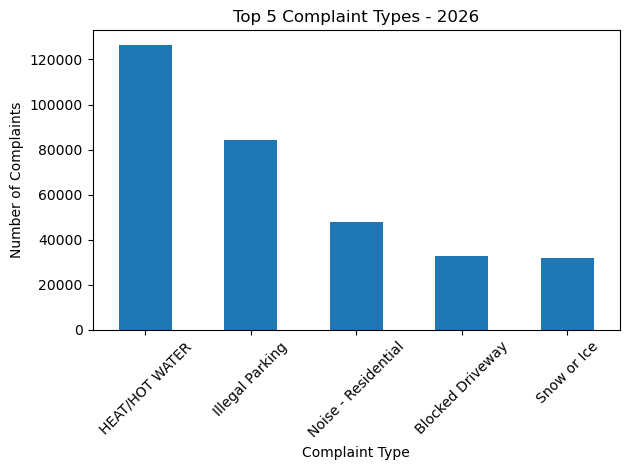

In [7]:
top5_problems = df['problem_(formerly_complaint_type)'].value_counts().head(5)
print(top5_problems)

# Visualization
plt.figure()
top5_problems.plot(kind='bar')
plt.title("Top 5 Complaint Types - 2026")
plt.xlabel("Complaint Type")
plt.ylabel("Number of Complaints")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

*Top 10 Problem Details*

problem_detail_(formerly_descriptor)
ENTIRE BUILDING                  80322
APARTMENT ONLY                   46290
Loud Music/Party                 29713
No Access                        26326
Blocked Hydrant                  24248
Banging/Pounding                 23854
Posted Parking Sign Violation    18472
Sidewalk                         17869
Blocked Sidewalk                 12302
Roadway                          10121
Name: count, dtype: int64


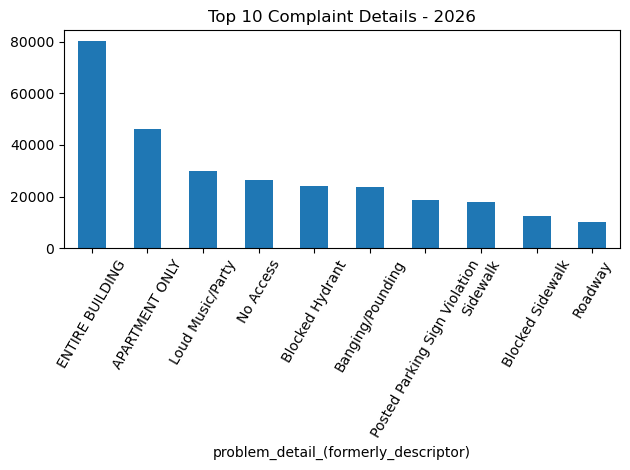

In [8]:
top10_details = df['problem_detail_(formerly_descriptor)'].value_counts().head(10)
print(top10_details)

plt.figure()
top10_details.plot(kind='bar')
plt.title("Top 10 Complaint Details - 2026")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

*Borough with Most Complaints*

borough
BROOKLYN         181181
QUEENS           136153
BRONX            129110
MANHATTAN        113151
STATEN ISLAND     23130
Unspecified         369
Name: count, dtype: int64


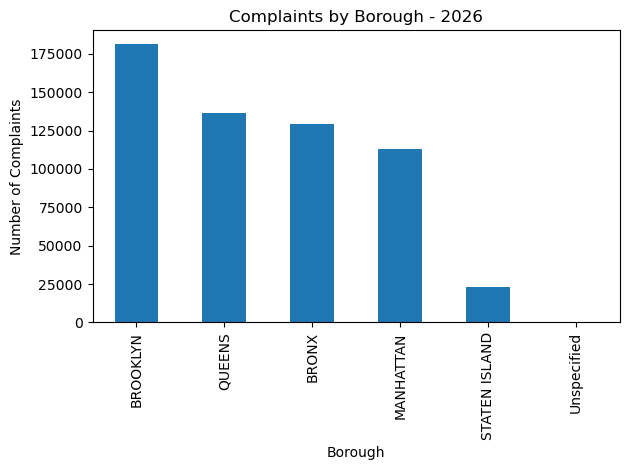

In [9]:
borough_counts = df['borough'].value_counts()
print(borough_counts)

plt.figure()
borough_counts.plot(kind='bar')
plt.title("Complaints by Borough - 2026")
plt.xlabel("Borough")
plt.ylabel("Number of Complaints")
plt.tight_layout()
plt.show()

*Avg Resolution Time*

In [10]:
# Resolution Time in hours
df['resolution_time_hours'] = (df['closed_date'] - df['created_date']).dt.total_seconds() / 3600

avg_resolution_time = df['resolution_time_hours'].mean()
print("Average Resolution Time (hours):", round(avg_resolution_time, 2))

Average Resolution Time (hours): 56.67


*Unresolved Complaints*

In [12]:
unresolved = df[df['status'] != 'Closed']
print("Number of Unresolved Complaints:", unresolved.shape[0])

Number of Unresolved Complaints: 86077


*Highest Complaints*

In [13]:
daily_counts = df.groupby(df['created_date'].dt.date).size()

max_date = daily_counts.idxmax()
max_count = daily_counts.max()

day_name = pd.to_datetime(max_date).day_name()

print("Highest Complaint Date:", max_date)
print("Number of Complaints:", max_count)
print("Day of Week:", day_name)

Highest Complaint Date: 2026-01-27
Number of Complaints: 19225
Day of Week: Tuesday


*Top 5 Highest Complaint Days*

In [14]:
top5_days = daily_counts.sort_values(ascending=False).head(5)
print(top5_days)

created_date
2026-01-27    19225
2026-01-28    16982
2026-01-26    15727
2026-02-01    15684
2026-01-30    15448
dtype: int64


*Top 10 Agencies by Complaints*

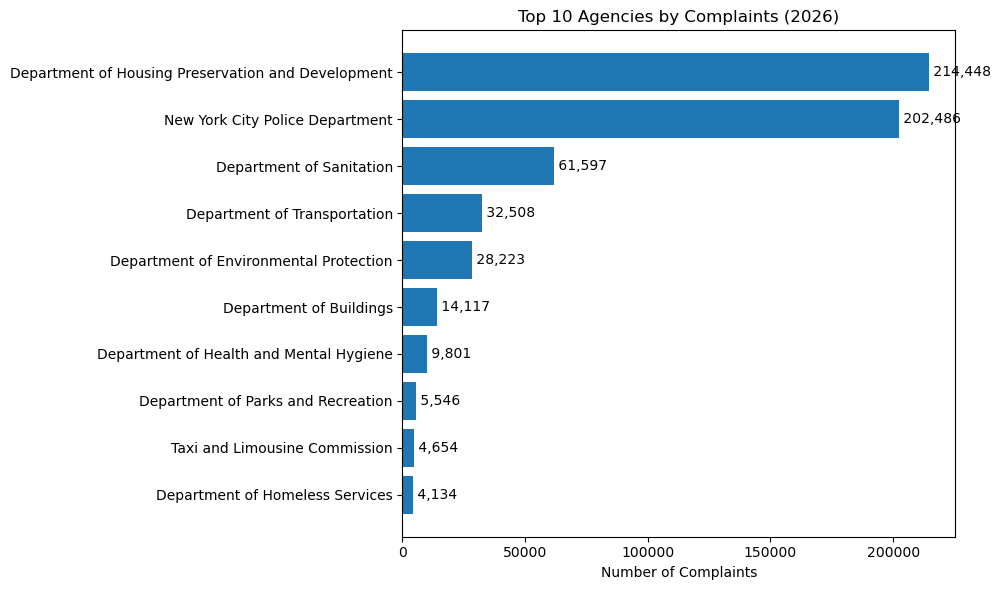

In [19]:
agency_counts = df['agency_name'].value_counts().head(10)
agency_counts = agency_counts.sort_values()

plt.figure(figsize=(10, 6))
bars = plt.barh(agency_counts.index, agency_counts.values)

plt.title("Top 10 Agencies by Complaints (2026)")
plt.xlabel("Number of Complaints")

# Add value labels
for i, v in enumerate(agency_counts.values):
    plt.text(v, i, f" {v:,}", va='center')

plt.tight_layout()
plt.show()

In [33]:
# Remove 'Unspecified' borough
df = df[df['borough'].str.lower() != 'unspecified']

*Animal-Related Complaints*

In [34]:
animal_keywords = ['dog', 'raccoon', 'animal', 'poop', 'pet']

animal_complaints = df[
    df['problem_(formerly_complaint_type)'].str.contains('|'.join(animal_keywords), case=False, na=False) |
    df['problem_detail_(formerly_descriptor)'].str.contains('|'.join(animal_keywords), case=False, na=False)
]

print("Total Animal Related Complaints:", animal_complaints.shape[0])

animal_summary = animal_complaints['problem_(formerly_complaint_type)'].value_counts()
print(animal_summary)

Total Animal Related Complaints: 6532
problem_(formerly_complaint_type)
Animal-Abuse                      1597
Dirty Condition                   1418
Noise                             1124
Dead Animal                        975
Animal in a Park                   501
Unsanitary Animal Pvt Property     394
Food Establishment                 207
Unleashed Dog                      190
Illegal Animal Kept as Pet          55
Pet Sale                            24
Highway Condition                   17
Animal Facility - No Permit         11
Unsanitary Animal Facility          10
Illegal Animal Sold                  6
Consumer Complaint                   3
Name: count, dtype: int64


*Dog Poop Complaints*

In [36]:
# Define keywords
dog_poop_keywords = ['dog poop', 'dog waste', 'dog feces','dog']

dog_poop_df = df[
    df['problem_(formerly_complaint_type)'].str.contains('|'.join(dog_poop_keywords), case=False, na=False) |
    df['problem_detail_(formerly_descriptor)'].str.contains('|'.join(dog_poop_keywords), case=False, na=False)
]

print("Total Dog Poop Complaints in 2026:", dog_poop_df.shape[0])

Total Dog Poop Complaints in 2026: 3292


In [37]:
borough_dog_poop = dog_poop_df['borough'].value_counts()

print(borough_dog_poop)

borough
BROOKLYN         1098
MANHATTAN         711
BRONX             702
QUEENS            690
STATEN ISLAND      91
Name: count, dtype: int64


In [38]:
highest_borough = borough_dog_poop.idxmax()
lowest_borough = borough_dog_poop.idxmin()

print("Borough with MOST dog poop complaints:", highest_borough)
print("Borough with LEAST dog poop complaints:", lowest_borough)

Borough with MOST dog poop complaints: BROOKLYN
Borough with LEAST dog poop complaints: STATEN ISLAND


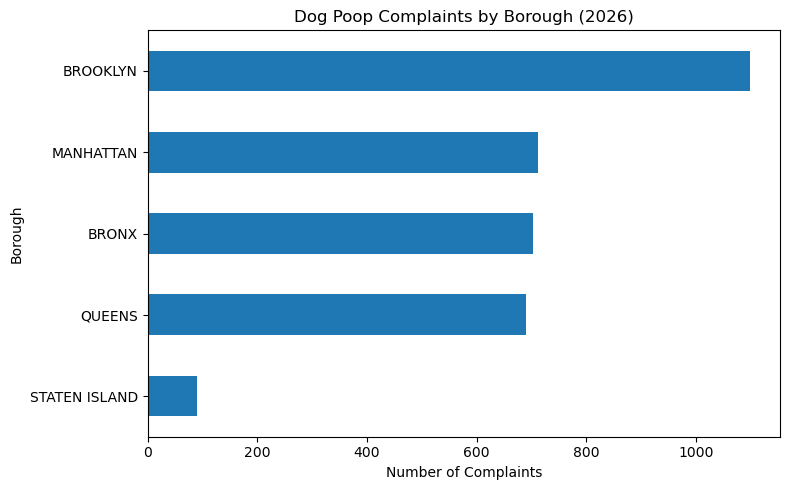

In [39]:
plt.figure(figsize=(8, 5))
borough_dog_poop.sort_values().plot(kind='barh')

plt.title("Dog Poop Complaints by Borough (2026)")
plt.xlabel("Number of Complaints")
plt.ylabel("Borough")

plt.tight_layout()
plt.show()